

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/HMM_InSample_Regime_Analysis_EquityBond.ipynb)

# **Corrélation indices actions-obligations : Description des régimes de marchés entre le S&P et le T-Bond 10y de 70 à 2025**

Ce code est de la description pure (full in-sample). Il initialise un HMM et le fit sur les log returns du S&P et du T-Bond 10y de 1970 à 2025 et identifie 4 régimes de marchés distincts. Pour comprendre ce que représente un régime, on utilise un objet de type RegimeStatisticalAnalyzer pour afficher les moyennes, volatilités et corrélations entre actifs conditionnellement à ce régime. Par ailleurs, des tests statistiques entre régimes sont appliqués (Levene pour les volatilités et Fisher-transfo pour les corrélations).


TO DO: rajouter le Box'M pour la matrice de cov complète





# Connection au github

In [1]:
import os
import sys

# 1. Vérification de l'environnement
if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 2. Clone du repo
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # 3. Déplacement dans le dossier du projet
    os.chdir(repo_name)

    # 4. Ajout du chemin au système pour l'import des modules .py
    sys.path.append(os.getcwd())

    print(f"Répertoire actuel : {os.getcwd()}")

Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 459, done.
remote: Counting objects: 100% (297/297), done.
remote: Compressing objects: 100% (289/289), done.
remote: Total 459 (delta 120), reused 4 (delta 4), pack-reused 162 (from 2)
Receiving objects: 100% (459/459), 19.52 MiB | 16.91 MiB/s, done.
Resolving deltas: 100% (158/158), done.
Répertoire actuel : /content/CorrelationEquityBond


# Installation de la librairie ssm via le repo git

In [2]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-d0mxndg6
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-d0mxndg6
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done
  Created wheel for ssm: filename=ssm-0.0.1-cp312-cp312-linux_x86_64.whl size=614351 sha256=d4b801131a1cd13bf63eff2dd5d376f9412627aac376f33e478a75d68210ccc8
  Stored in directory: /tmp/pip-ephem-wheel-cache-y6kuq4wg/wheels/a8/a9/68/b62b9b4d4ee3afda66bd9eec0cb2fbc9a79a7504e9d6d17397
Successfully built ssm


# Préparation des données

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("monthly_data/dataset_stat_app_vf_with_gold.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.drop(columns="Unnamed: 0", inplace=True)

In [10]:
ASSET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
asset_names = ["S&P", "T-bond 10y"]
annualise_factor = np.sqrt(12) # mensuel

cols = ASSET_VARS
df_model = df[cols].dropna().copy()
Y_raw = df_model[ASSET_VARS].values.astype(float)

dates = df_model.index
split_date = pd.Timestamp("2025-01-01") # on fait de la description ici

train_mask = (dates <= split_date) & (dates >= pd.Timestamp("1970-01-01")) # on commence l'analyse en 70
dates_train = dates[train_mask]
Y_train_raw = Y_raw[train_mask]

T, D = Y_raw.shape
SEED = 120
np.random.seed(SEED)

data_to_fit = [Y_train_raw*100] # * 100 pour stabilité numérique


# Initialisation et fit du HMM descriptif

In [11]:
from RegimeDetector.HMMRegimeDetector import HMMRegimeDetector
from RegimeDetector.RegimeStatisticalAnalyzer import RegimeStatisticalAnalyzer

# Modèle HMM
detector = HMMRegimeDetector(
    n_regimes=4,
    n_dim=2,
    random_state=42
)

detector.fit(Y=data_to_fit)
states = detector.viterbi_states

# Analyseur Statistique
analyzer = RegimeStatisticalAnalyzer(
    Y=data_to_fit[0],
    states=states,
    asset_names=asset_names
)

# Print lisible des résultats des tests
results = analyzer.full_report(
    n_boot=5000,
    alpha=0.05,
    annualise=annualise_factor,
    correction="bonferroni",
    seed=42
)

STATISTIQUES DESCRIPTIVES PAR RÉGIME

--- Régime 0  (n = 88) ---
                        S&P:  moy = -2.2931   vol = 5.9963  (ann. 20.7719)
                 T-bond 10y:  moy = +1.0210   vol = 1.8315  (ann. 6.3444)
  Matrice de corrélation:
[[ 1.     -0.4558]
 [-0.4558  1.    ]]

--- Régime 1  (n = 345) ---
                        S&P:  moy = +1.4199   vol = 2.7362  (ann. 9.4785)
                 T-bond 10y:  moy = +0.6813   vol = 1.7565  (ann. 6.0848)
  Matrice de corrélation:
[[1.     0.3873]
 [0.3873 1.    ]]

--- Régime 2  (n = 65) ---
                        S&P:  moy = +0.3880   vol = 4.7638  (ann. 16.5024)
                 T-bond 10y:  moy = +0.1230   vol = 3.9185  (ann. 13.5741)
  Matrice de corrélation:
[[1.    0.283]
 [0.283 1.   ]]

--- Régime 3  (n = 163) ---
                        S&P:  moy = +1.5767   vol = 2.0273  (ann. 7.0228)
                 T-bond 10y:  moy = +0.0826   vol = 1.3841  (ann. 4.7945)
  Matrice de corrélation:
[[ 1.     -0.1467]
 [-0.1467  1.    ]]

TEST 

On semble donc identifier 4 régimes de marchés disincts

1.   Flight-to-quality (correl négative, haute vol, typique de 2008 ou 2020)
2.   Normal (correl positive, vol basse)
3.   Stress inflationniste (correl positive, haute vol, typique des années 70 ou de 2022)
4.   Diversification idéale (correl négative, vol basse vol, pré-2010)



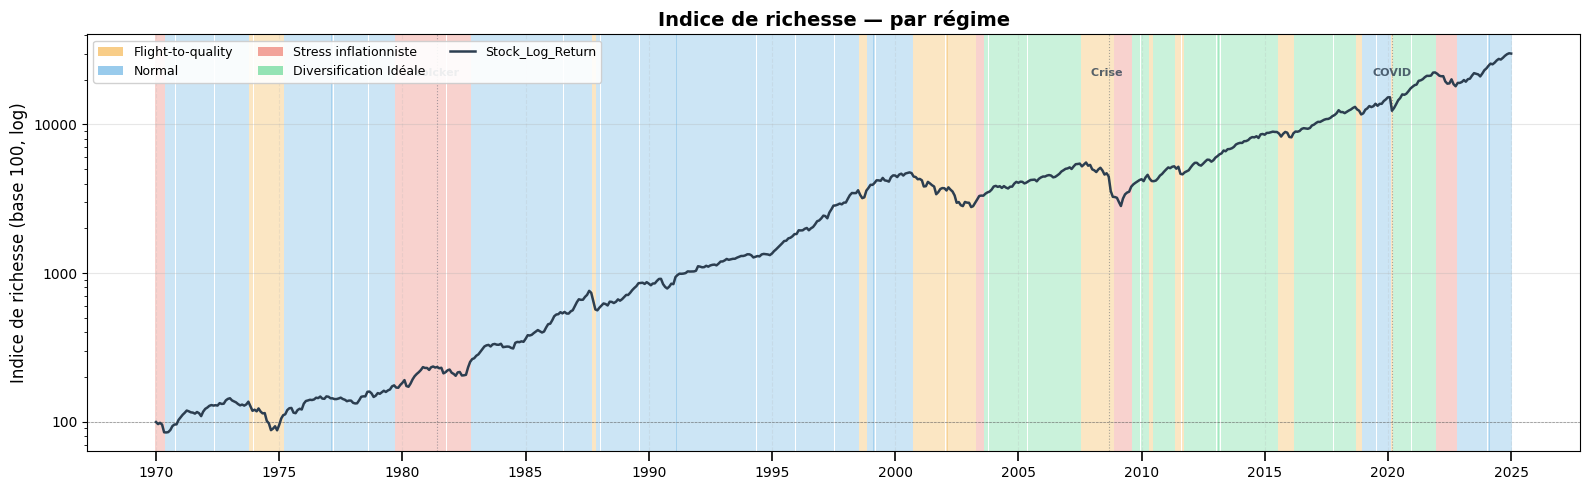

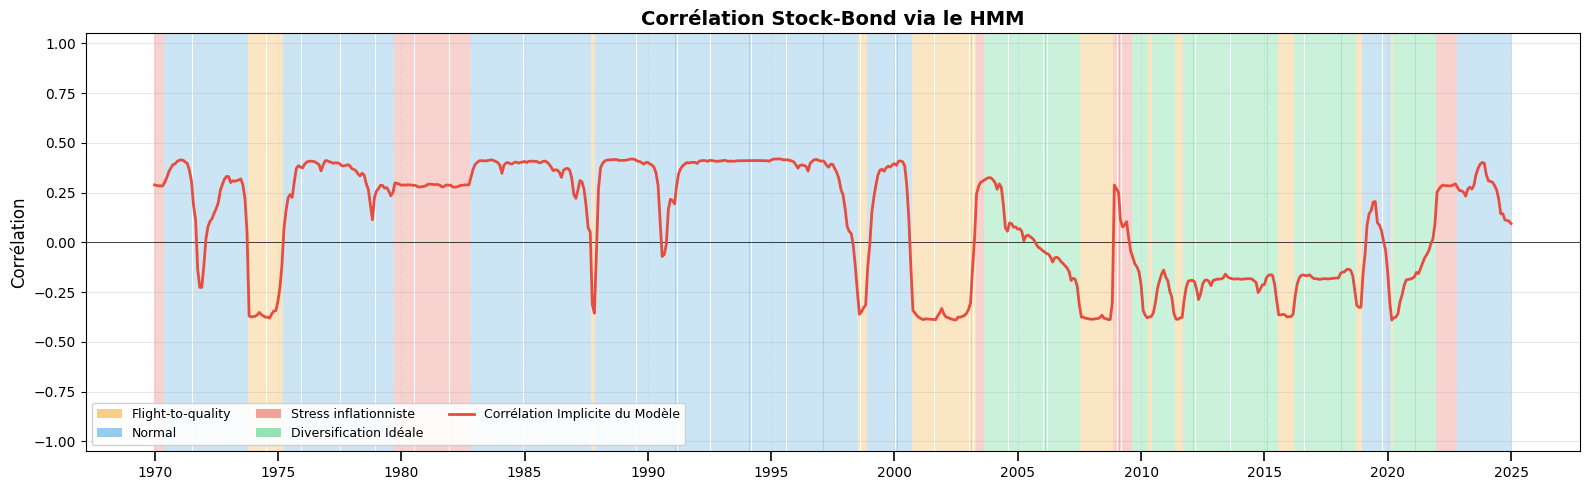

In [12]:
from RegimeDetector.RegimeVisualizer import RegimeVisualizer

mes_labels = {0: "Flight-to-quality", 1: "Normal", 2: "Stress inflationniste", 3: "Diversification Idéale"} # les 4 régimes identifiés
mes_couleurs = {0:"#f39c12", 1: "#3498db", 2: "#e74c3c", 3: "#2ecc71"} # choix des couleurs
mes_crises = {"Volcker": "1981-06-01", "Crise ": "2008-09-01","COVID": "2020-03-01",} # quelques dates pour les identifier + facilement

# Instanciation générique
visualizer = RegimeVisualizer(
    detector=detector,
    Y=data_to_fit[0],
    dates=dates_train,
    states=states,
    asset_names=["Stock_Log_Return", "Bond_Log_Return"],
    regime_labels=mes_labels,
    regime_colors=mes_couleurs,
    events_dict=mes_crises
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation()